# Exploring Novae results

In [1]:
# %% Libraries
import os
import scanpy as sc
#import scvi
import numpy as np
from pathlib import Path
import pandas as pd
import anndata as ad
import rapids_singlecell as rsc
import novae

In [2]:
# %% Setting Paths
MAIN_DIR_NAME = "cosmx_gray"
MAIN_DIR = next(p for p in Path.cwd().parents if (p / MAIN_DIR_NAME).exists()) / MAIN_DIR_NAME
os.chdir(MAIN_DIR)

# %% Setting Seed
SEED_VALUE = 42
# set NumPy RNG for consistency
np.random.seed(SEED_VALUE)

# %% object versions
CUR_OBJ_V = 'v9'
NEW_OVJ_V = 'v10'
CUR_OBJ_PATH = MAIN_DIR / 'data' / 'old_comb' / 'h5ad' / f'comb_{CUR_OBJ_V}.h5ad'
NEW_OBJ_PATH = MAIN_DIR / 'data' / 'old_comb' / 'h5ad' / f'comb_{NEW_OVJ_V}.h5ad'

# %% Load the unintegrated object
comb = sc.read_h5ad(CUR_OBJ_PATH)

In [3]:
model1 = novae.Novae.from_pretrained("data/old_comb/novae_model")
model1

Loading weights from local directory


Novae model
   ├── Known genes: 60697
   ├── Parameters: 32.1M
   ├── Model name: data/old_comb/novae_model
   ├── Trained: True
   └── Multimodal: False

In [4]:
comb

AnnData object with n_obs × n_vars = 1326786 × 6175
    obs: 'fov', 'Area', 'AspectRatio', 'Width', 'Height', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD68', 'Max.CD68', 'Mean.Membrane', 'Max.Membrane', 'Mean.CD45', 'Max.CD45', 'Mean.DAPI', 'Max.DAPI', 'SplitRatioToLocal', 'NucArea', 'NucAspectRatio', 'Circularity', 'Eccentricity', 'Perimeter', 'Solidity', 'assay_type', 'version', 'Run_Tissue_name', 'Panel', 'cellSegmentationSetId', 'cellSegmentationSetName', 'slide_ID', 'CenterX_global_px', 'CenterY_global_px', 'unassignedTranscripts', 'median_RNA', 'RNA_quantile_0.75', 'RNA_quantile_0.8', 'RNA_quantile_0.85', 'RNA_quantile_0.9', 'RNA_quantile_0.95', 'RNA_quantile_0.99', 'nCount_RNA', 'nFeature_RNA', 'median_negprobes', 'negprobes_quantile_0.75', 'negprobes_quantile_0.8', 'negprobes_quantile_0.85', 'negprobes_quantile_0.9', 'negprobes_quantile_0.95', 'negprobes_quantile_0.99', 'nCount_negprobes', 'nFeature_negprobes', 'median_falsecode', 'falsecode_quantile_0.75', 'falsecode_quantile_0.8', 'f

## UMAP from novae spatial domains

In [ ]:
rsc.pp.neighbors(comb, use_rep="novae_latent_corrected", key_added="nb_novae", random_state=SEED_VALUE, n_neighbors=50)


In [ ]:
rsc.tl.umap(comb, neighbors_key="nb_novae", random_state=SEED_VALUE, key_added='umap_novae')

In [ ]:
# Replace X_umap with integrated UMAP embeddings
comb.obsm['X_umap'] =  comb.obsm["umap_novae"]

# visualize clusters

sc.pl.umap(
    comb,
    color=["novae_domains_7", "sample_name"],
    size=0.5,
    frameon=False,
    legend_loc='on data',
    return_fig = False,
    show=False,
)

## Spatial PAthway Analysis

In [ ]:
!pwd


Plotting pathway scores for sample: CTRL01


[INFO] (novae.plot._heatmap) Loaded 50 pathway(s)
/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/scanpy/tools/_score_genes.py:163: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[score_name] = pd.Series(
[INFO] (novae.plot._heatmap) Plot mode: 50 pathways scores per domain


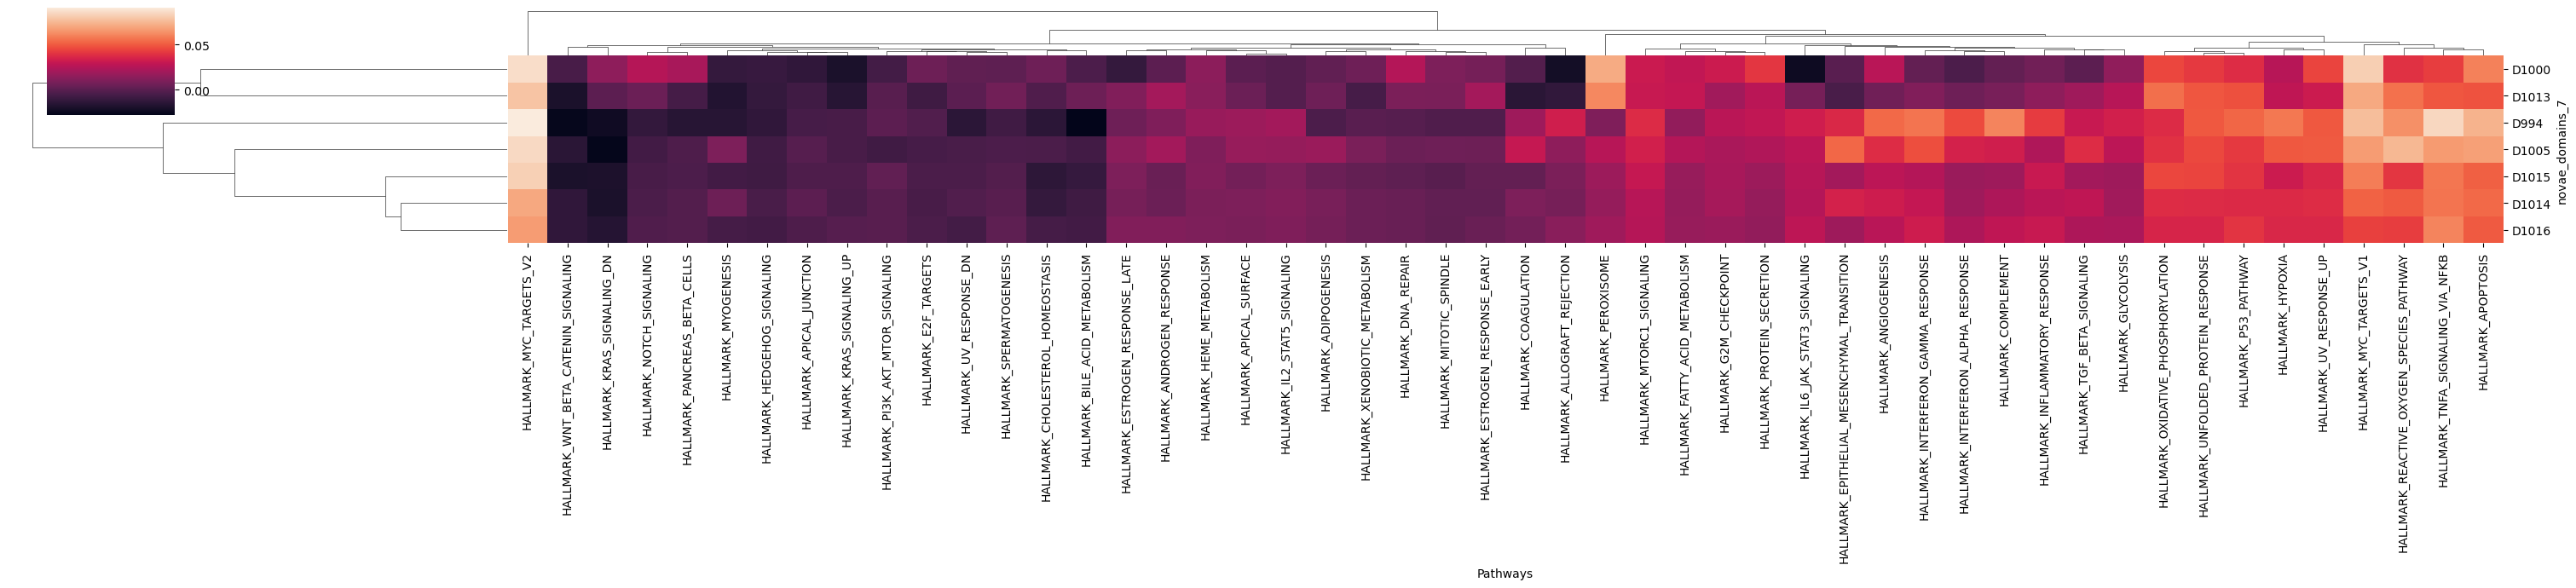

Plotting pathway scores for sample: PWCF01_1


[INFO] (novae.plot._heatmap) Loaded 50 pathway(s)
/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/scanpy/tools/_score_genes.py:163: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[score_name] = pd.Series(
[INFO] (novae.plot._heatmap) Plot mode: 50 pathways scores per domain


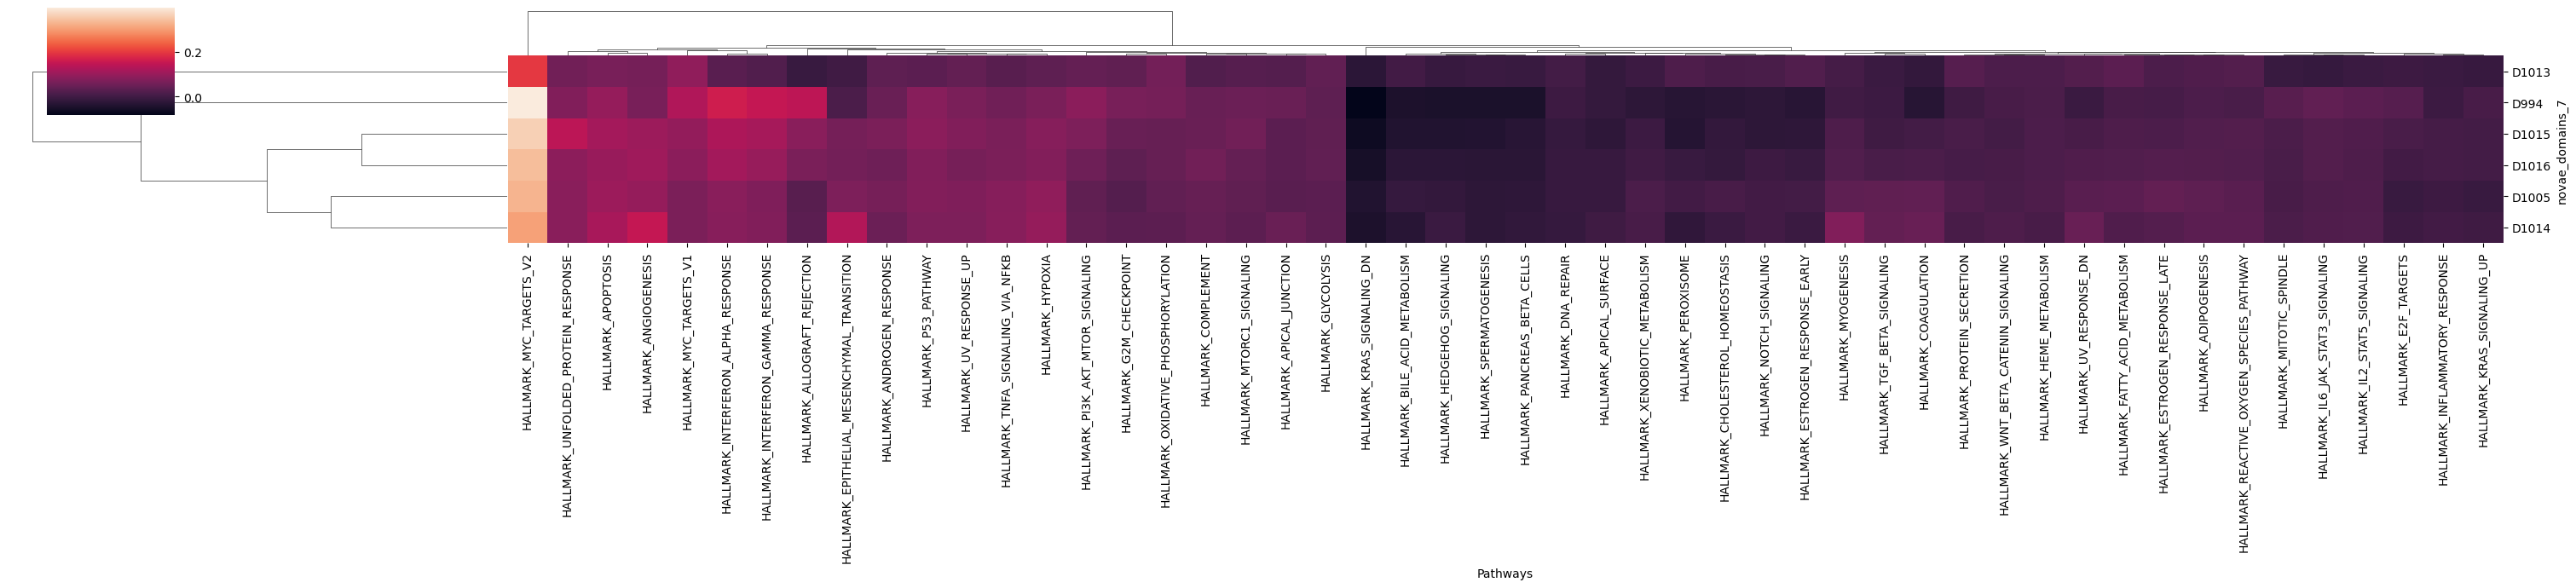

Plotting pathway scores for sample: PWCF05


[INFO] (novae.plot._heatmap) Loaded 50 pathway(s)
/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/scanpy/tools/_score_genes.py:163: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[score_name] = pd.Series(
[INFO] (novae.plot._heatmap) Plot mode: 50 pathways scores per domain


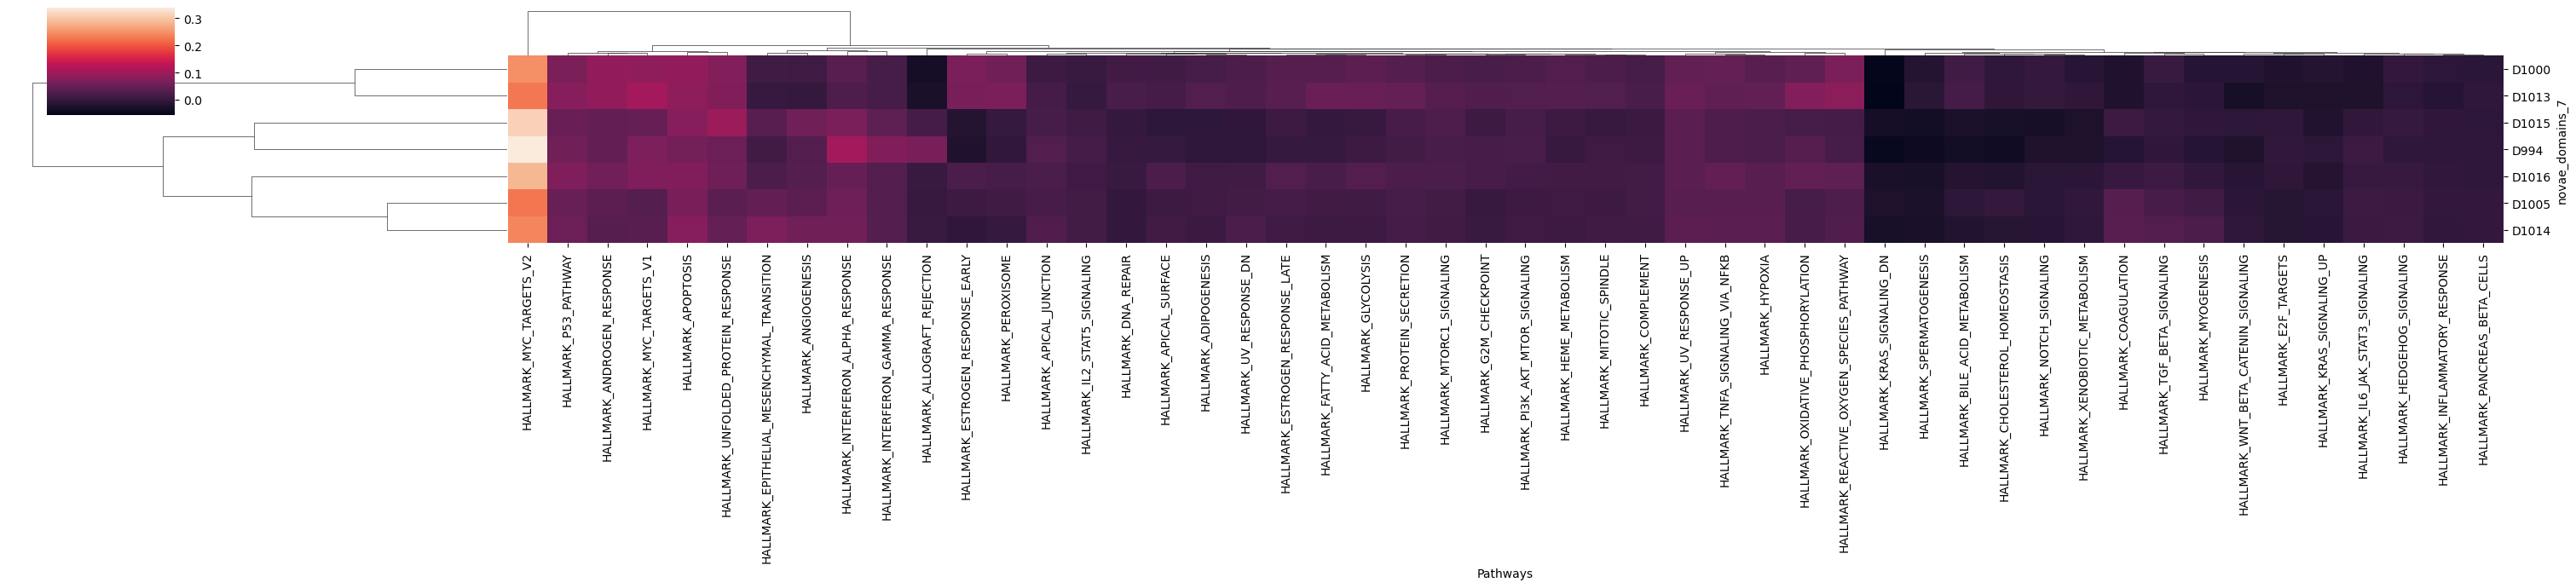

Plotting pathway scores for sample: PWCF02


[INFO] (novae.plot._heatmap) Loaded 50 pathway(s)
/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/scanpy/tools/_score_genes.py:163: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[score_name] = pd.Series(
[INFO] (novae.plot._heatmap) Plot mode: 50 pathways scores per domain


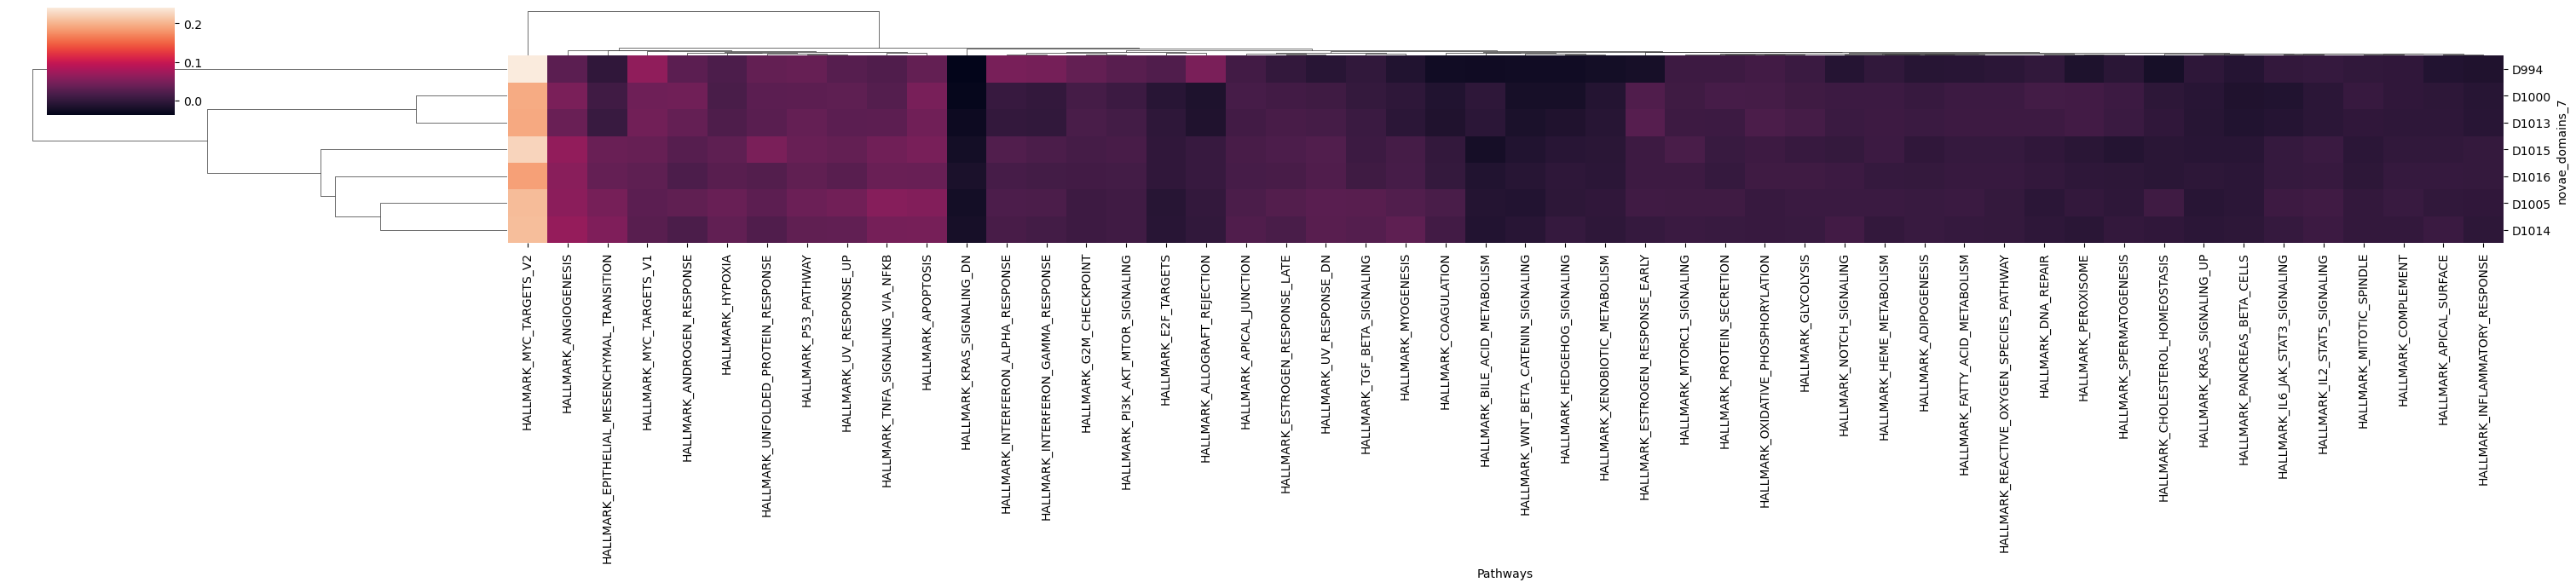

Plotting pathway scores for sample: PWCF03


[INFO] (novae.plot._heatmap) Loaded 50 pathway(s)
/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/scanpy/tools/_score_genes.py:163: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[score_name] = pd.Series(
[INFO] (novae.plot._heatmap) Plot mode: 50 pathways scores per domain


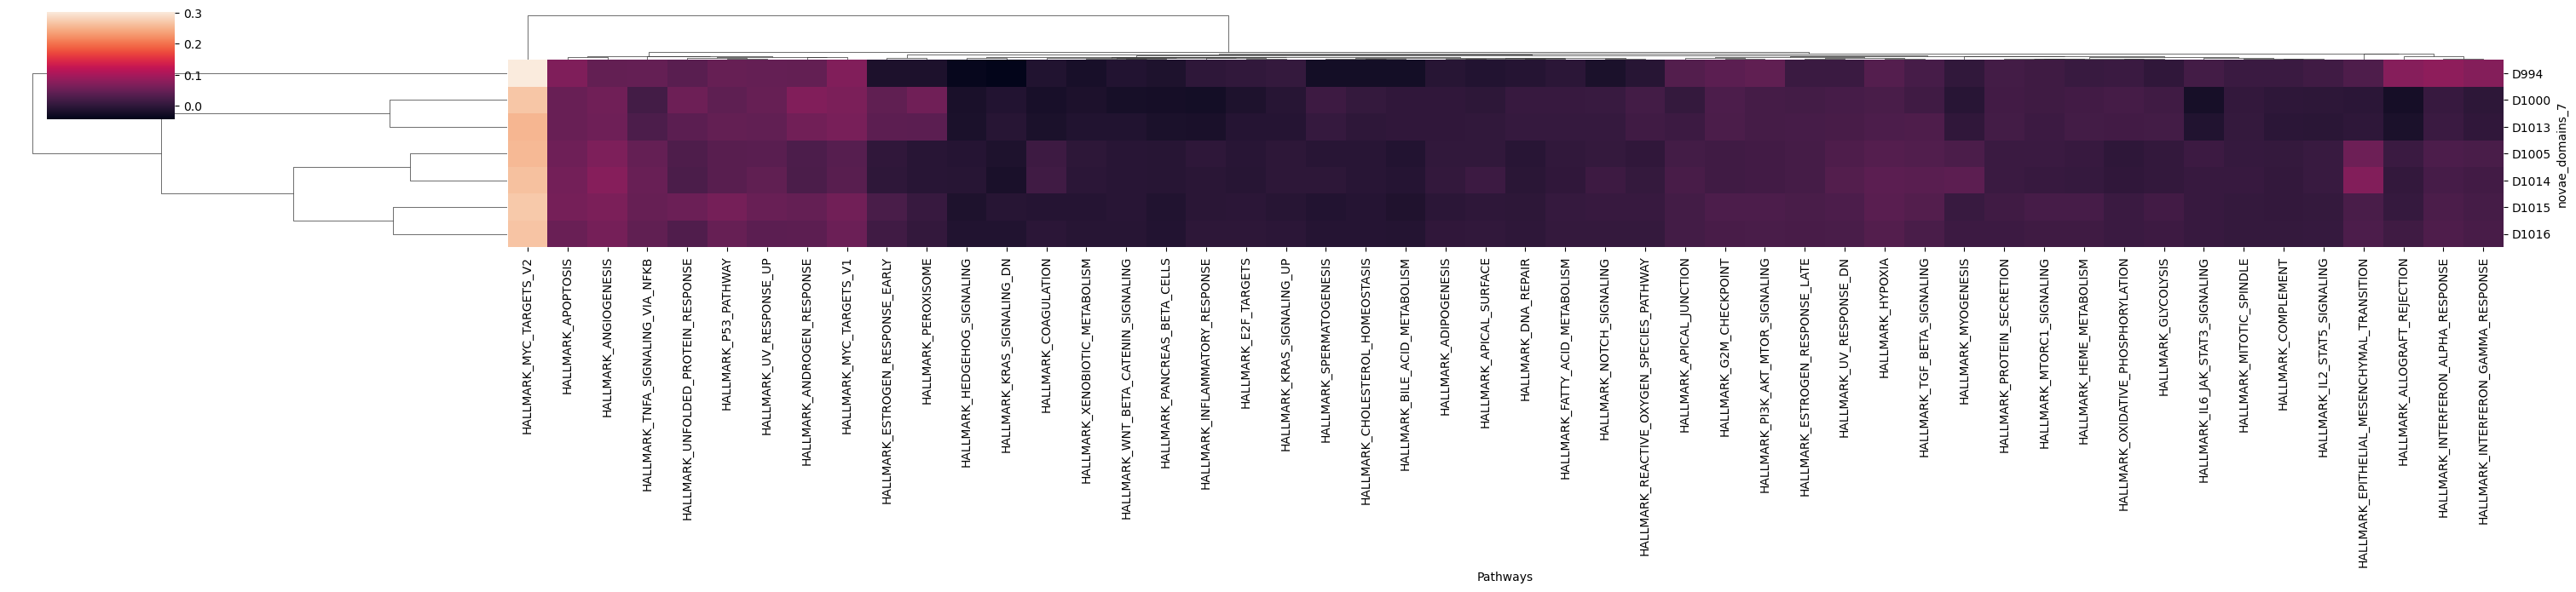

[INFO] (novae.plot._heatmap) Loaded 50 pathway(s)


Plotting pathway scores for sample: PWCF04


/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/scanpy/tools/_score_genes.py:163: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[score_name] = pd.Series(
[INFO] (novae.plot._heatmap) Plot mode: 50 pathways scores per domain


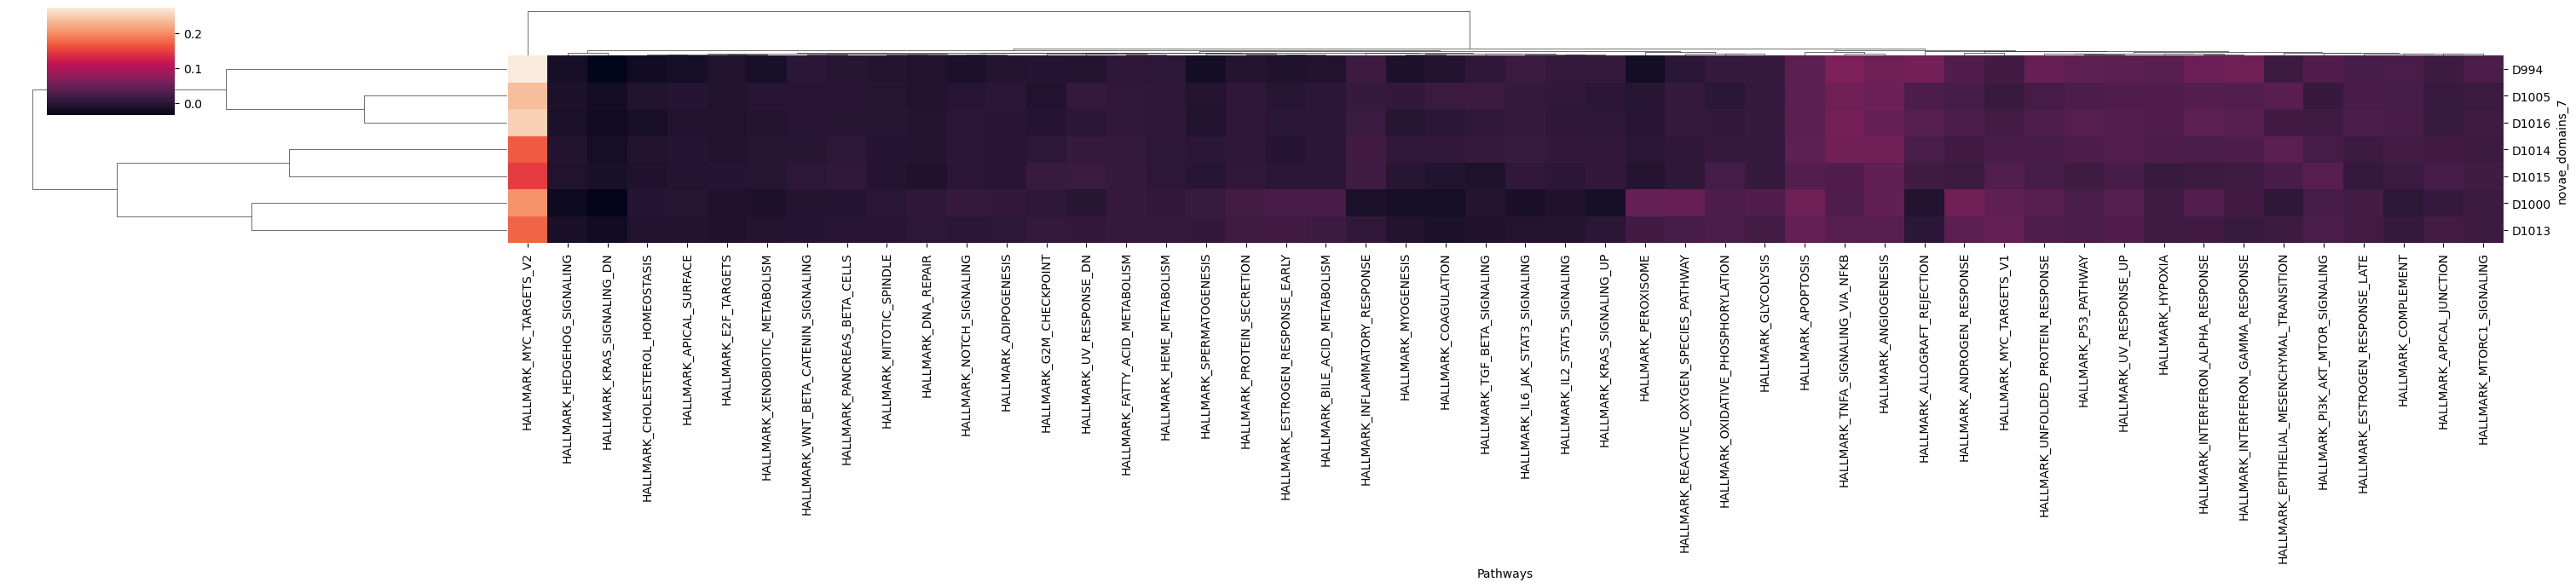

[INFO] (novae.plot._heatmap) Loaded 50 pathway(s)


Plotting pathway scores for sample: CTRL05


/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/scanpy/tools/_score_genes.py:163: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[score_name] = pd.Series(
[INFO] (novae.plot._heatmap) Plot mode: 50 pathways scores per domain


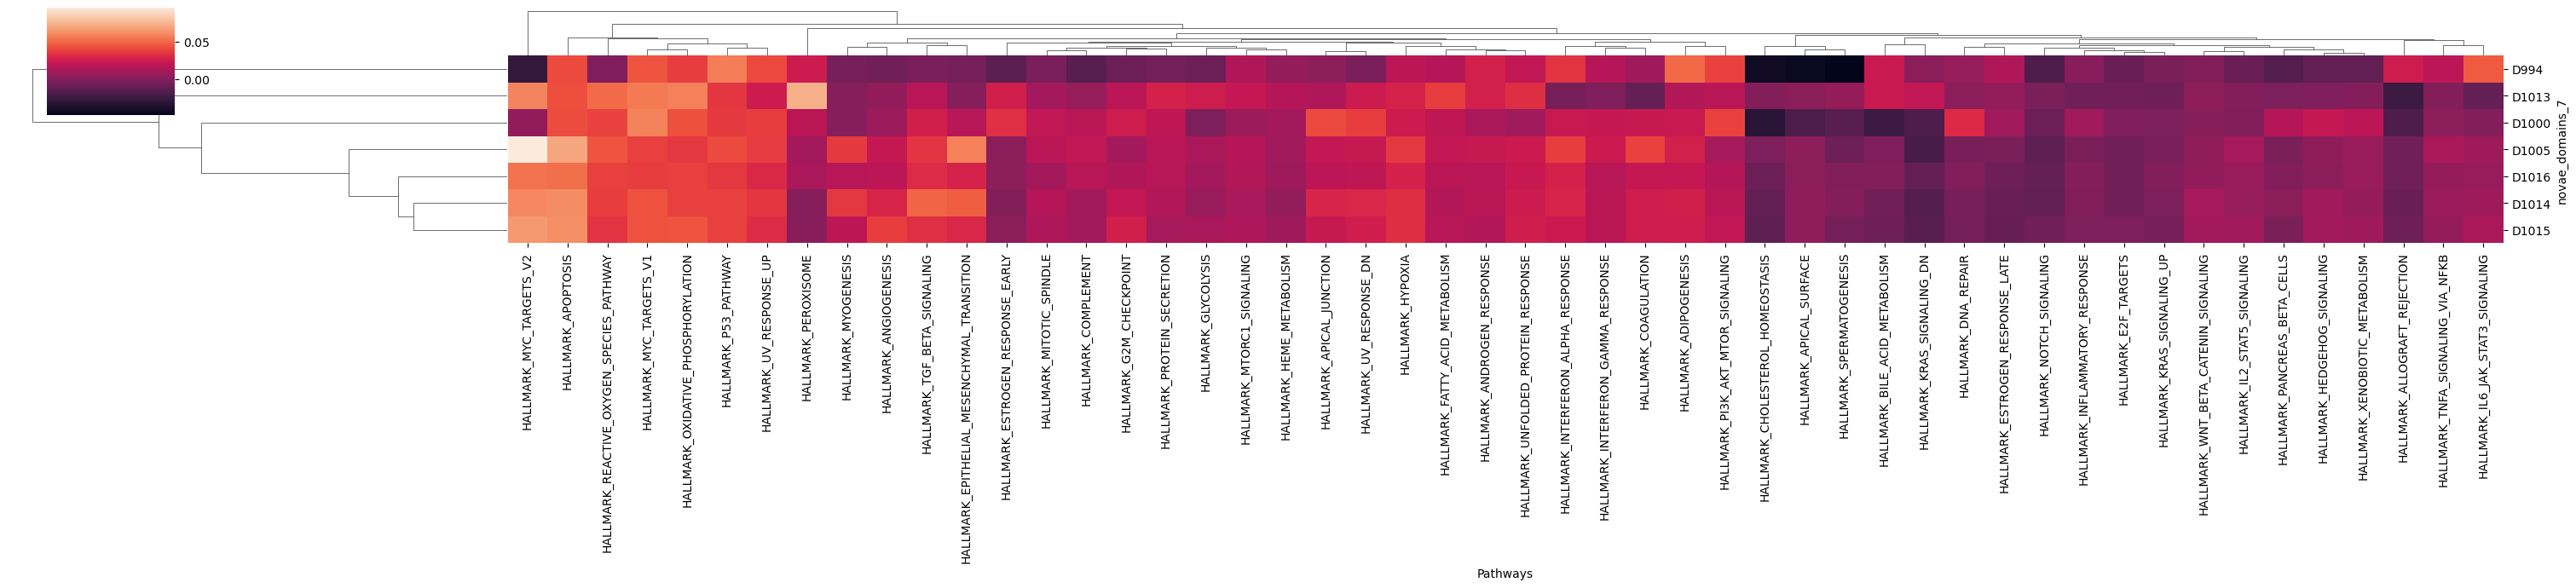

[INFO] (novae.plot._heatmap) Loaded 50 pathway(s)


Plotting pathway scores for sample: CTRL02


/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/scanpy/tools/_score_genes.py:163: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[score_name] = pd.Series(
[INFO] (novae.plot._heatmap) Plot mode: 50 pathways scores per domain


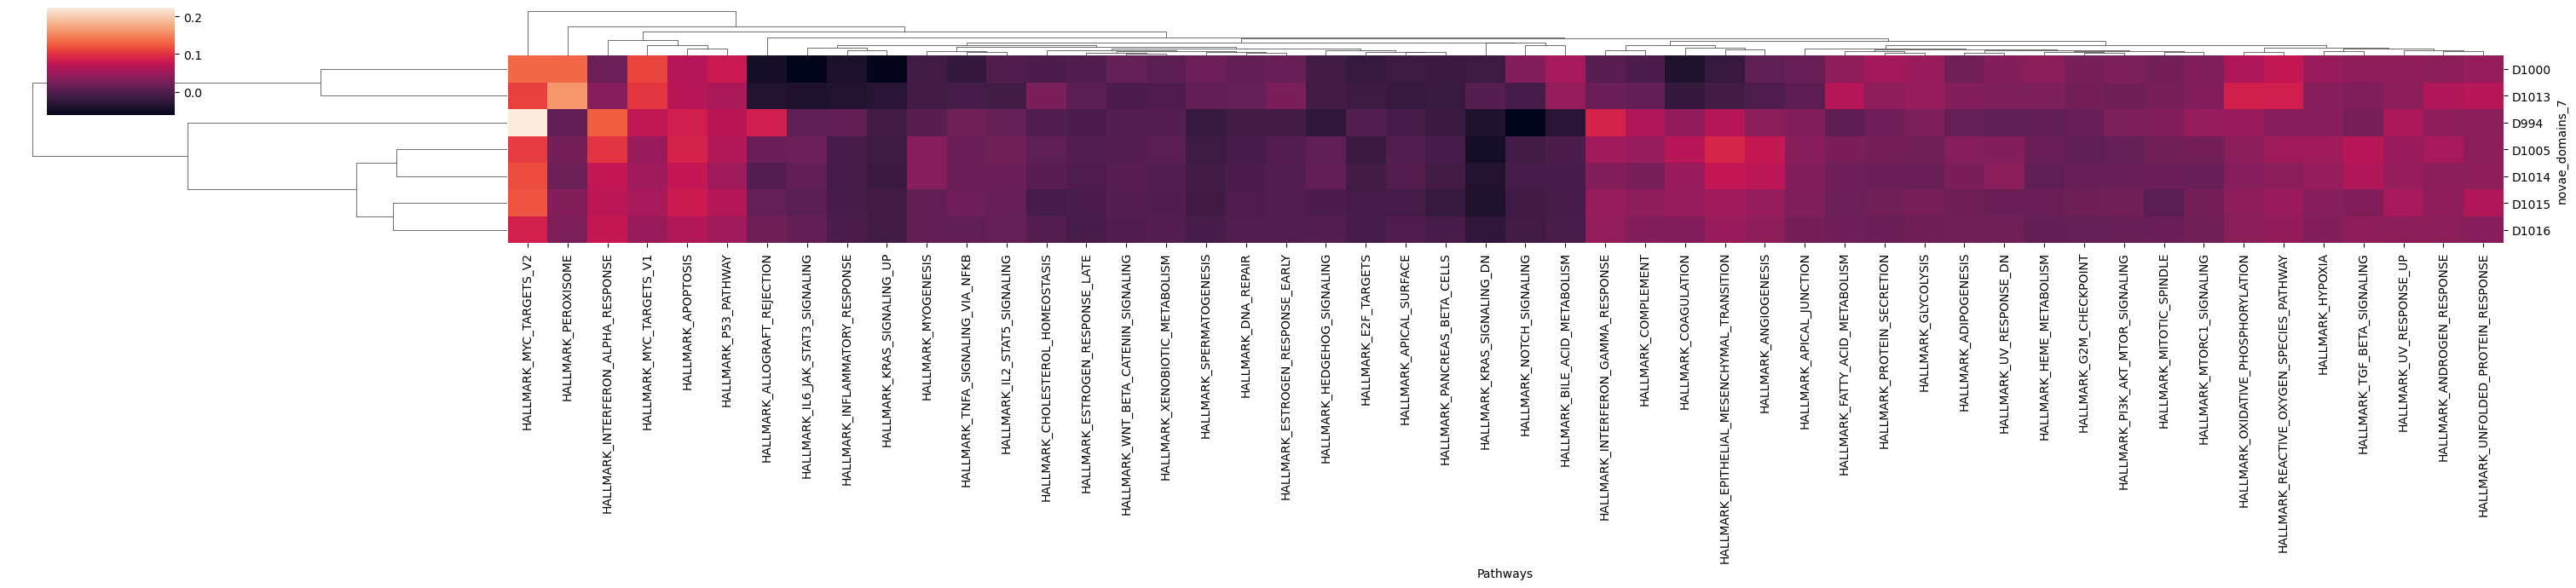

[INFO] (novae.plot._heatmap) Loaded 50 pathway(s)


Plotting pathway scores for sample: CTRL03


/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/scanpy/tools/_score_genes.py:163: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[score_name] = pd.Series(
[INFO] (novae.plot._heatmap) Plot mode: 50 pathways scores per domain


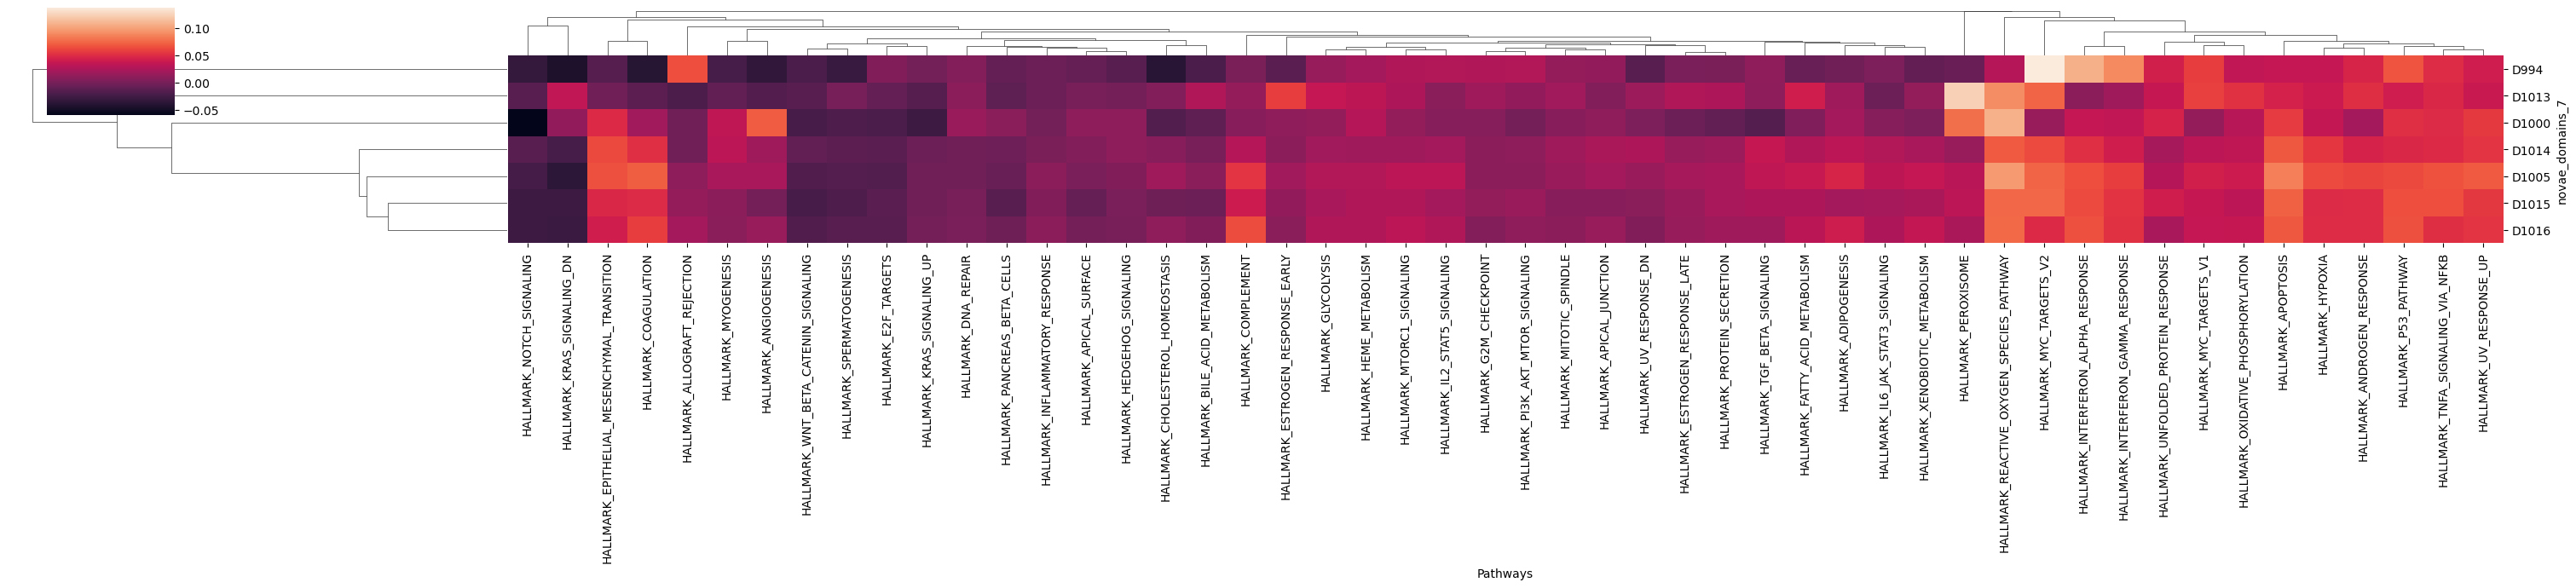

[INFO] (novae.plot._heatmap) Loaded 50 pathway(s)


Plotting pathway scores for sample: CTRL04


/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/scanpy/tools/_score_genes.py:163: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[score_name] = pd.Series(
[INFO] (novae.plot._heatmap) Plot mode: 50 pathways scores per domain


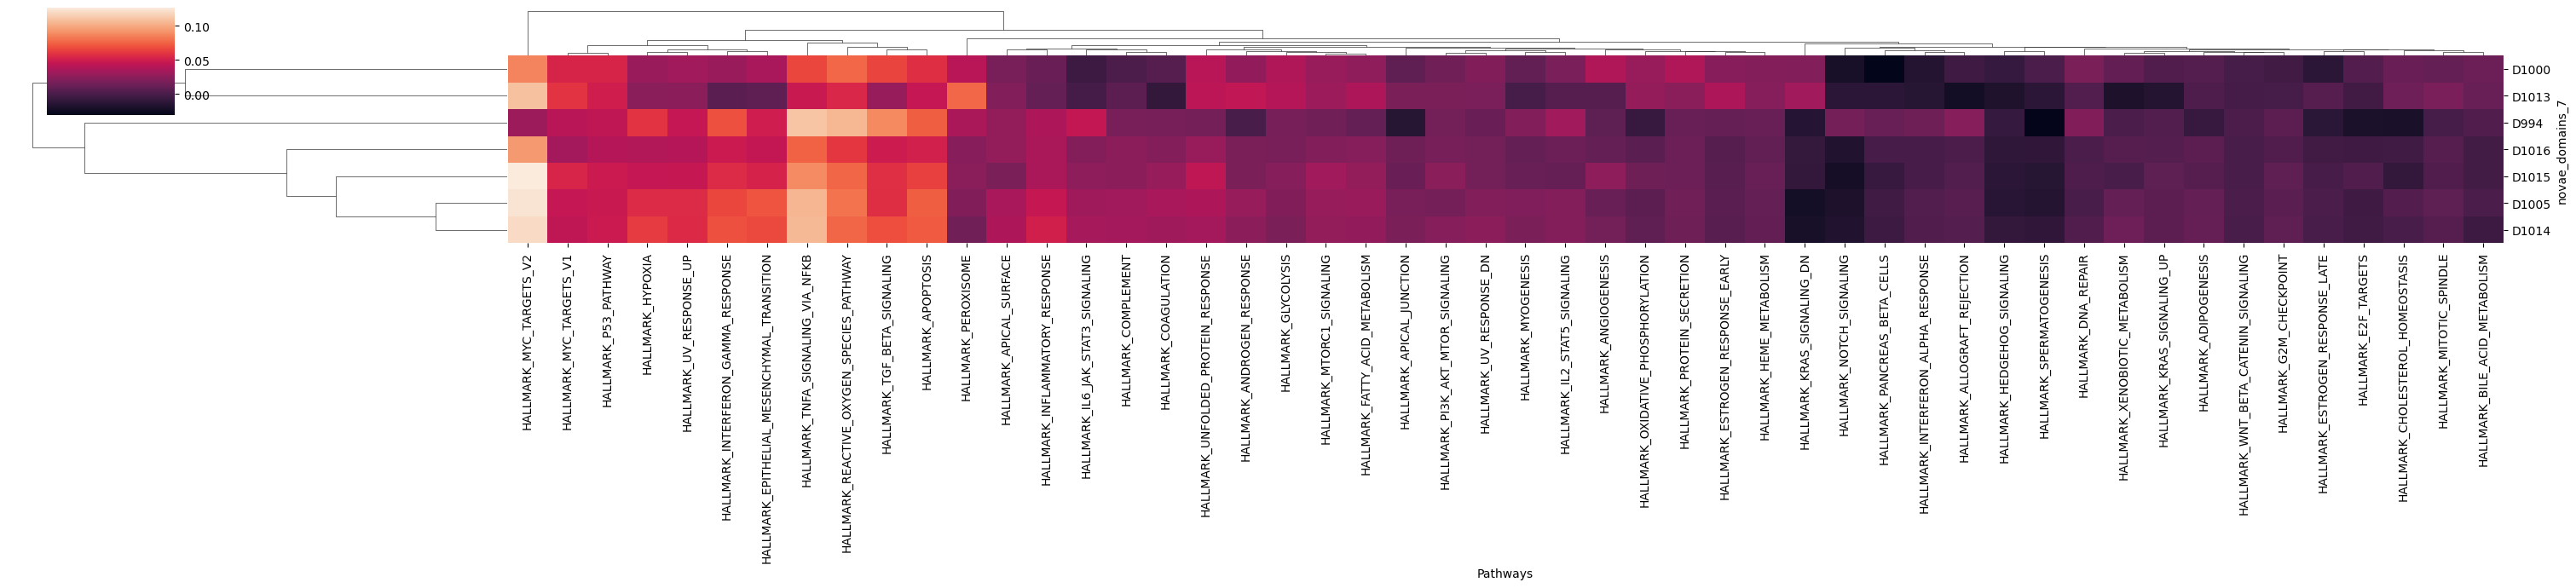

Plotting pathway scores for sample: PWCF01_2


[INFO] (novae.plot._heatmap) Loaded 50 pathway(s)
/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/scanpy/tools/_score_genes.py:163: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[score_name] = pd.Series(
[INFO] (novae.plot._heatmap) Plot mode: 50 pathways scores per domain


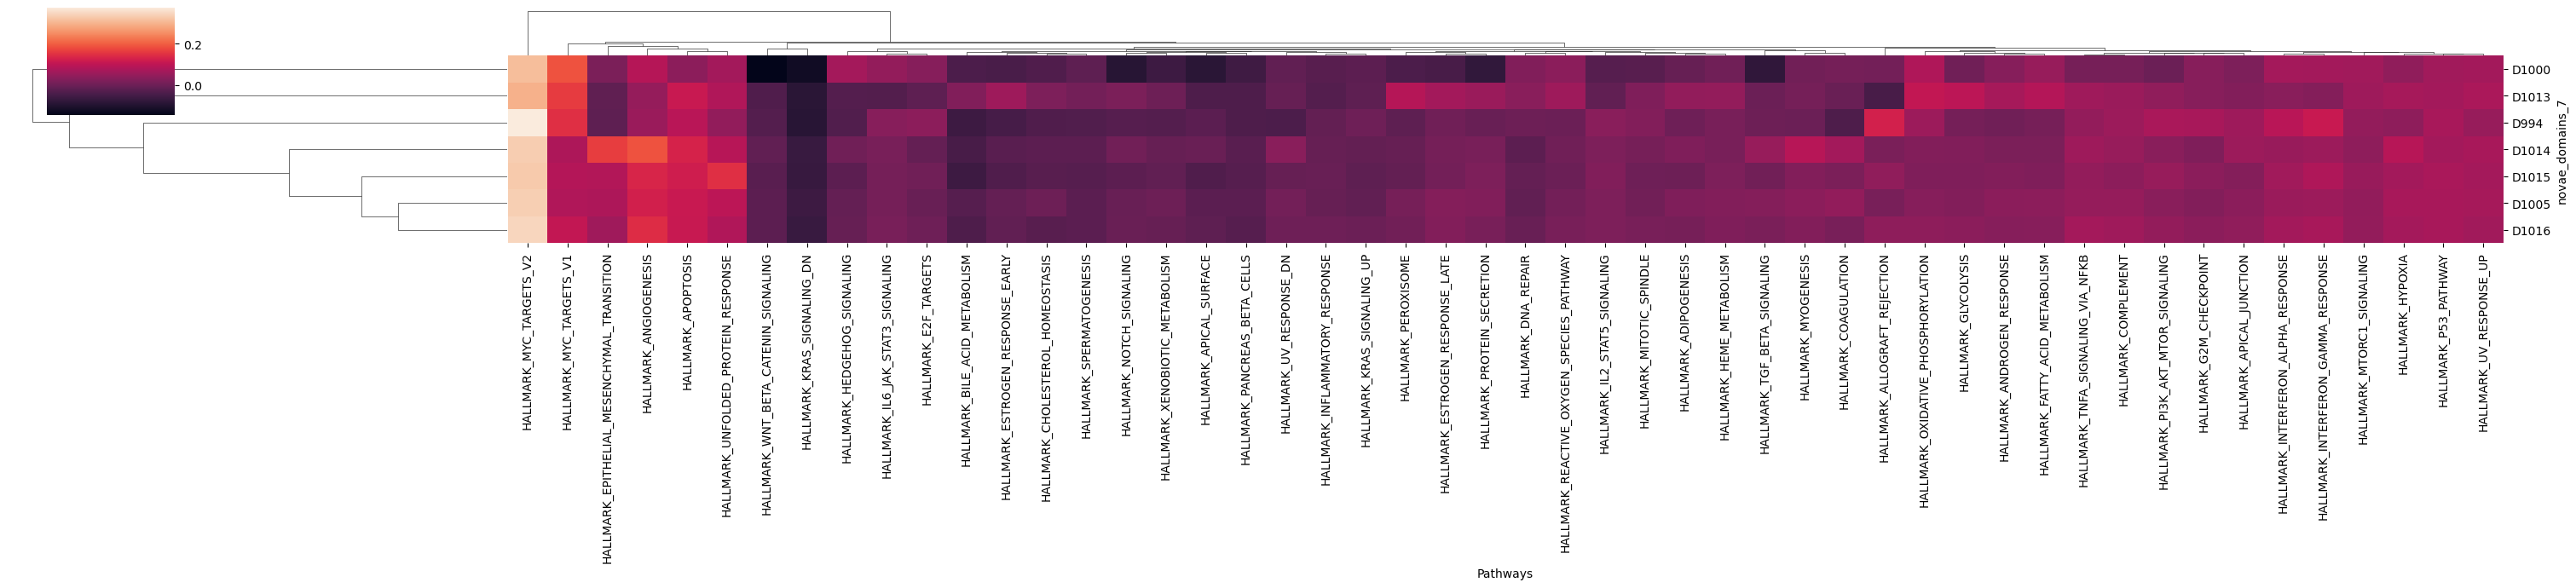

Plotting pathway scores for sample: PWCF06


[INFO] (novae.plot._heatmap) Loaded 50 pathway(s)
/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/scanpy/tools/_score_genes.py:163: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[score_name] = pd.Series(
[INFO] (novae.plot._heatmap) Plot mode: 50 pathways scores per domain


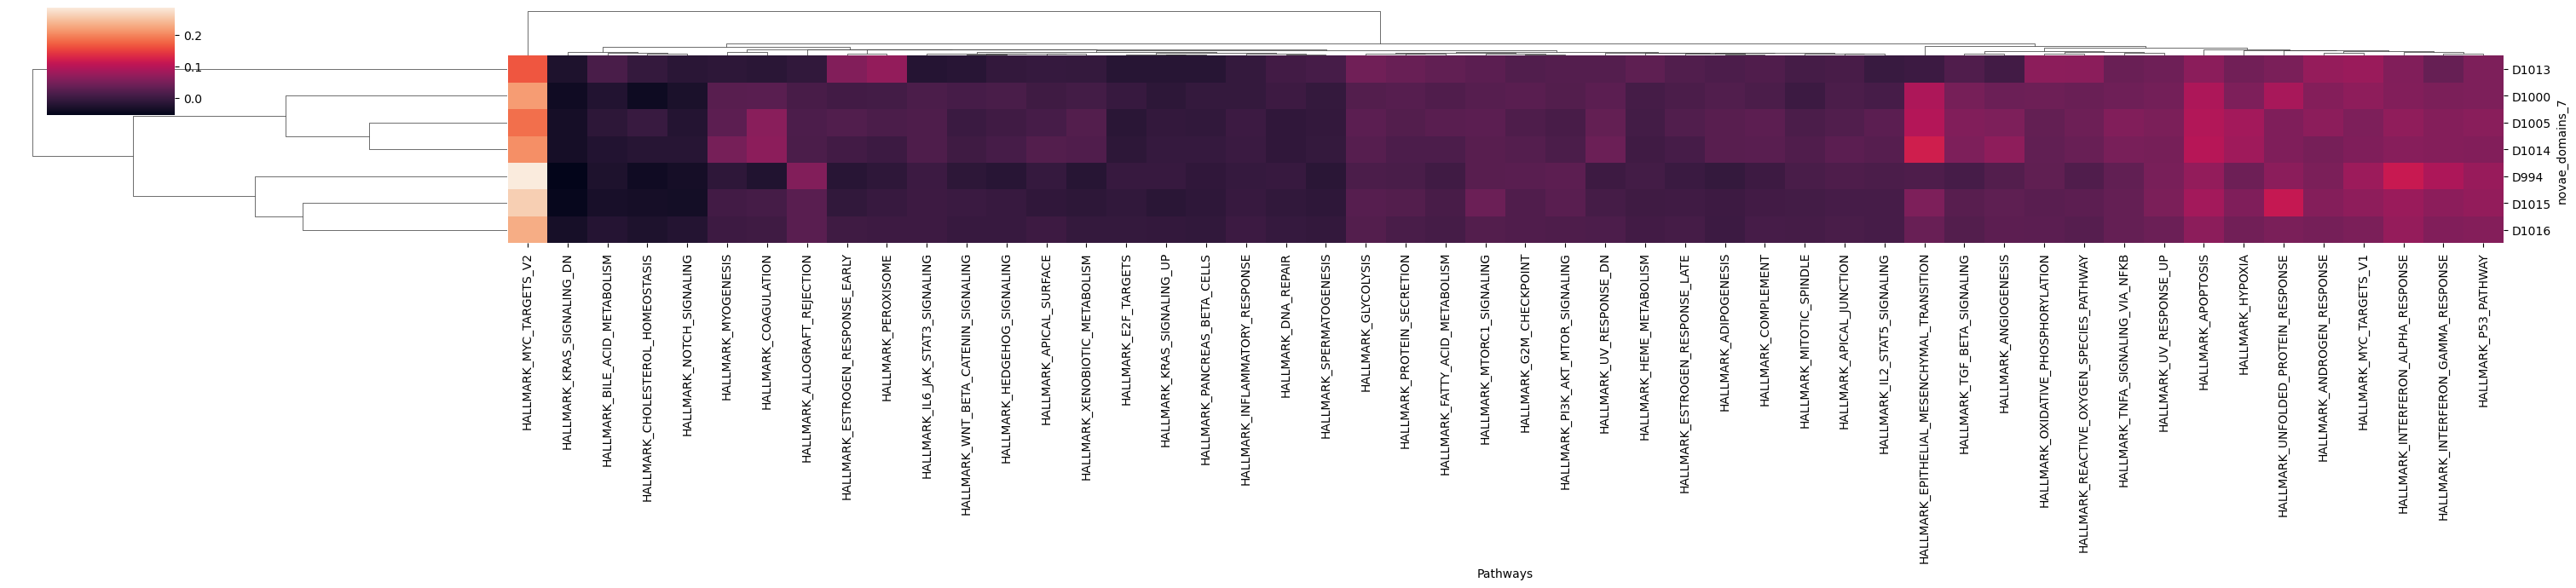

In [6]:
hallmarks_file = "/mnt/data/project0062/cosmx_gray/code/5_niche_analysis/human_hallmarks.json"
sample_names = comb.obs['sample_name'].unique()
for sample in sample_names:
    print(f"Plotting pathway scores for sample: {sample}")
    sub = comb[comb.obs['sample_name'] == sample]
    novae.plot.pathway_scores(
        sub, 
        obs_key="novae_domains_7",
        pathways=hallmarks_file, 
        figsize=(30, 7)
    )

[INFO] (novae.plot._heatmap) Loaded 50 pathway(s)
[INFO] (novae.plot._heatmap) Plot mode: 50 pathways scores per domain


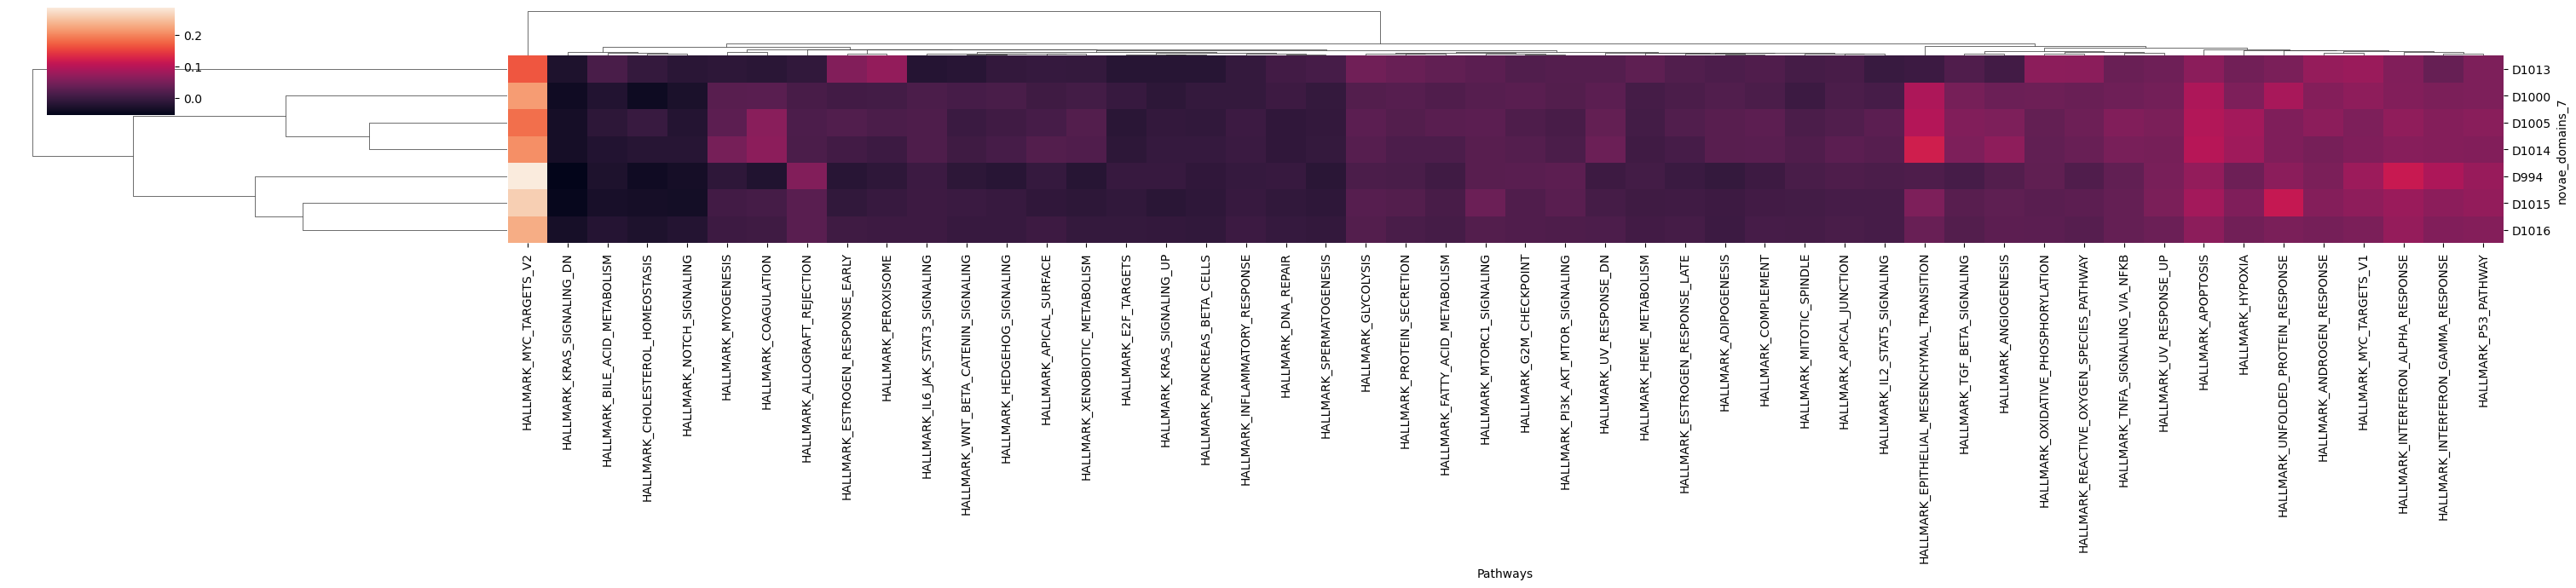

Pathways,HALLMARK_TNFA_SIGNALING_VIA_NFKB,HALLMARK_HYPOXIA,HALLMARK_CHOLESTEROL_HOMEOSTASIS,HALLMARK_MITOTIC_SPINDLE,HALLMARK_WNT_BETA_CATENIN_SIGNALING,HALLMARK_TGF_BETA_SIGNALING,HALLMARK_IL6_JAK_STAT3_SIGNALING,HALLMARK_DNA_REPAIR,HALLMARK_G2M_CHECKPOINT,HALLMARK_APOPTOSIS,...,HALLMARK_HEME_METABOLISM,HALLMARK_COAGULATION,HALLMARK_IL2_STAT5_SIGNALING,HALLMARK_BILE_ACID_METABOLISM,HALLMARK_PEROXISOME,HALLMARK_ALLOGRAFT_REJECTION,HALLMARK_SPERMATOGENESIS,HALLMARK_KRAS_SIGNALING_UP,HALLMARK_KRAS_SIGNALING_DN,HALLMARK_PANCREAS_BETA_CELLS
novae_domains_7,,,,,,,,,,,,,,,,,,,,,
D1000,0.042025,0.053304,-0.041429,-0.001023,0.008784,0.047790,0.012030,-0.000182,0.024675,0.090326,...,0.007212,0.025011,0.008905,-0.023514,0.005412,0.009743,-0.006846,-0.014706,-0.040142,-0.007318
D1005,0.056046,0.083374,-0.004117,0.011913,-0.001601,0.056355,0.014974,-0.010990,0.015148,0.094404,...,0.006418,0.062591,0.025864,-0.013812,0.011852,0.013364,-0.008820,-0.008293,-0.034994,-0.009553
D1013,0.037144,0.044766,-0.007452,0.007038,-0.017552,0.016017,-0.021255,0.003982,0.017691,0.063569,...,0.028533,-0.016373,-0.003800,0.011206,0.070725,-0.010079,0.008537,-0.020020,-0.027292,-0.019074
D1014,0.049754,0.080534,-0.019185,0.015772,0.002077,0.053822,0.014769,-0.011108,0.020356,0.099394,...,0.003175,0.064933,0.022320,-0.023035,-0.000629,0.012450,-0.007629,-0.006832,-0.034899,-0.006010
D1015,0.033665,0.054982,-0.035482,0.005213,-0.001897,0.022474,0.000618,-0.010391,0.016934,0.083213,...,0.001833,0.006673,0.008405,-0.032390,-0.005406,0.024377,-0.012313,-0.016679,-0.048244,-0.012648
D1016,0.033905,0.043687,-0.026983,0.007206,-0.004904,0.019391,-0.000159,-0.005697,0.016503,0.065241,...,0.004519,0.002266,0.008500,-0.020656,0.000760,0.024872,-0.009253,-0.009248,-0.033422,-0.009537
D994,0.031134,0.040357,-0.040143,0.010570,-0.013922,0.008653,-0.001354,-0.004510,0.024629,0.070239,...,0.006285,-0.024435,0.011822,-0.027880,-0.013001,0.057430,-0.016417,-0.005018,-0.054643,-0.012144


In [8]:
novae.plot.pathway_scores(
        sub, 
        obs_key="novae_domains_7",
        pathways=hallmarks_file, 
        figsize=(30, 7),
        return_df=True,
    )